## ⚡ EWRouter

**Concepts:** [Constructive heuristics](../routers.md#constructive-heuristics) · [Optimization approaches](../routers.md#optimization-approaches) **Advanced API:** [⚡ Constructive Heuristics](lo20_heuristic.ipynb)

This notebook uses `OptiWindNet` to route the collector system cables via [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter).

### EWRouter (Esau-Williams Heuristic)

[EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) is a _fast and lightweight heuristic router_ based on the _Esau-Williams algorithm_ — see [Constructive heuristics](../routers.md#constructive-heuristics) for how the heuristic works and how its variants differ.

> [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) is the default router used in [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork). If no router is specified when creating a [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance, [.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) will automatically run with [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter).

#### Constructor: `EWRouter(...)`

All arguments of [EWRouter()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) are optional; [method](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.method) selects the heuristic variant, and the variants are compared in [Constructive heuristics](../routers.md#constructive-heuristics).

The full signature — [maxiter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.maxiter), [feeder_route](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.feeder_route), [method](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.method), [bias_margin](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.bias_margin), [verbose](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.verbose) — is documented in the API Reference under [optiwindnet.api.EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter).

**Example**

```python
# Implicit use of EWRouter as default
wf = WindFarmNetwork(cables=..., turbinesC=..., substationsC=...)
wf.optimize() # Uses EWRouter by default

# Explicitly use with custom options
router = EWRouter(feeder_route='straight', maxiter=5000)
wf = WindFarmNetwork(cables=..., turbinesC=..., substationsC=..., router=router)
wf.optimize()

# Ringed (closed-loop) topology
router = EWRouter(method='ringed')
wf = WindFarmNetwork(cables=..., turbinesC=..., substationsC=..., router=router)
wf.optimize()
```

> While [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) is very efficient, it’s a _heuristic_ and does _not guarantee globally optimal_ solutions. Use it when you need speed or when solving large problems where exact optimization is too slow.

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter

create an instance of `wfn` using [.from_pbf()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.from_pbf)

In [2]:
wfn = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=[(7, 2000.0)])

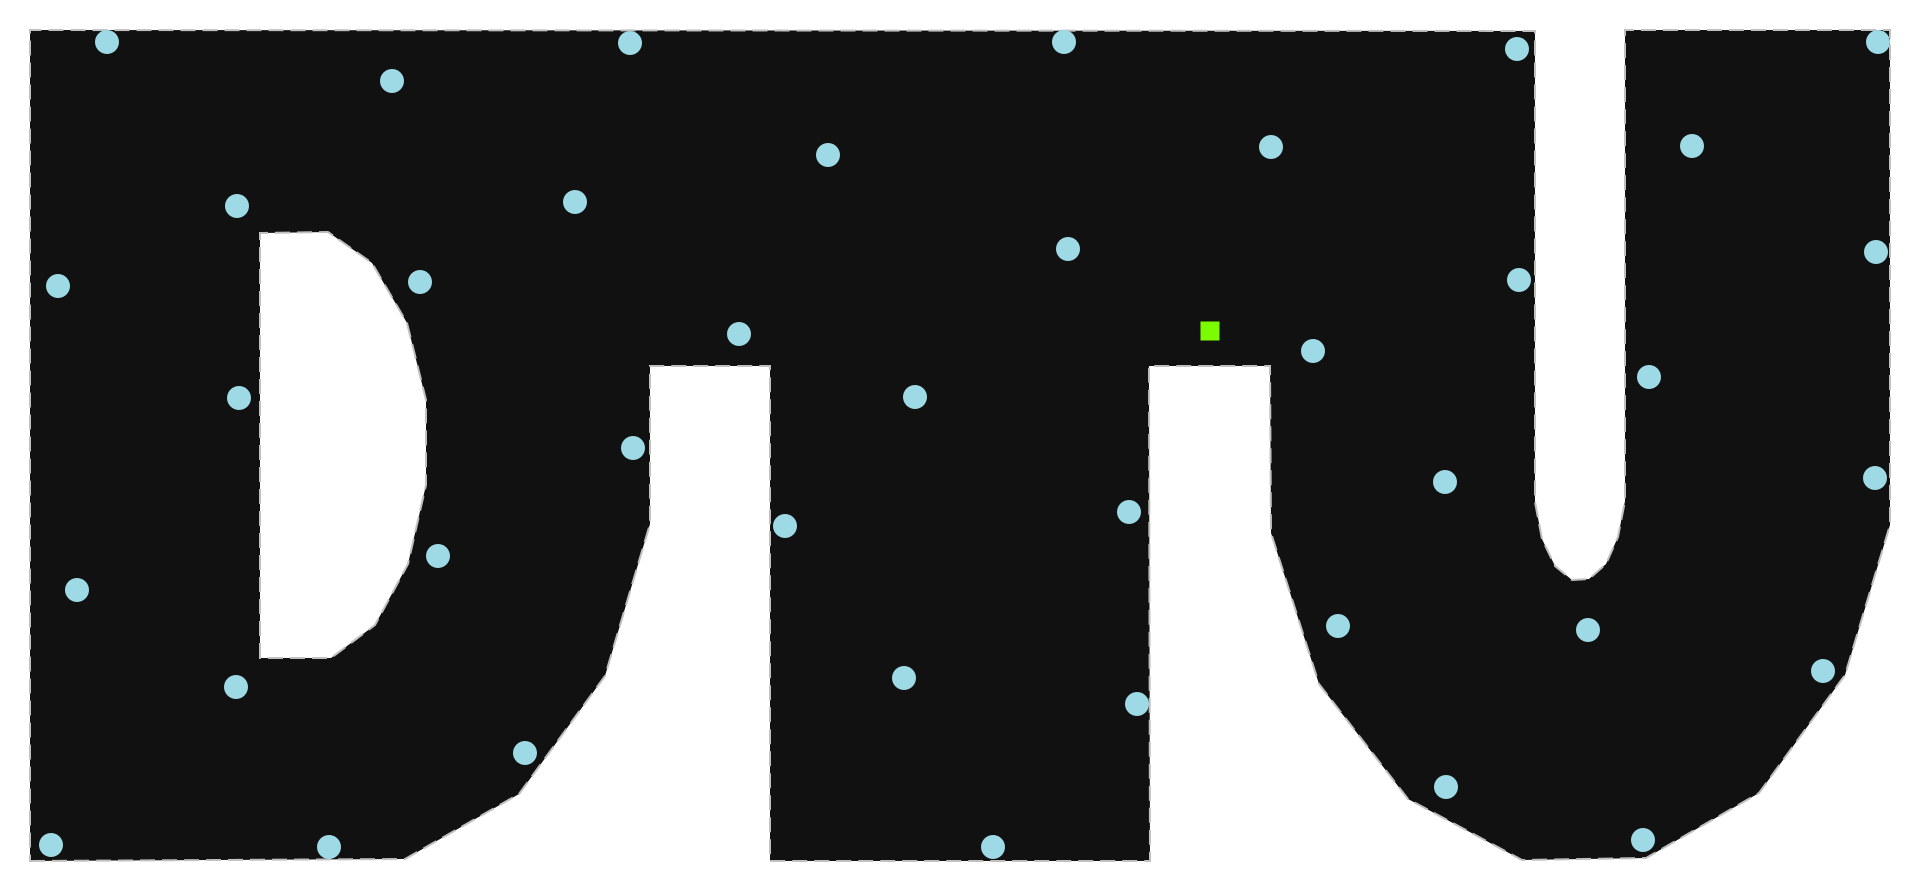

In [3]:
wfn

### Optimize with EWRouter

#### Optimize with default settings.

1647.108905210097


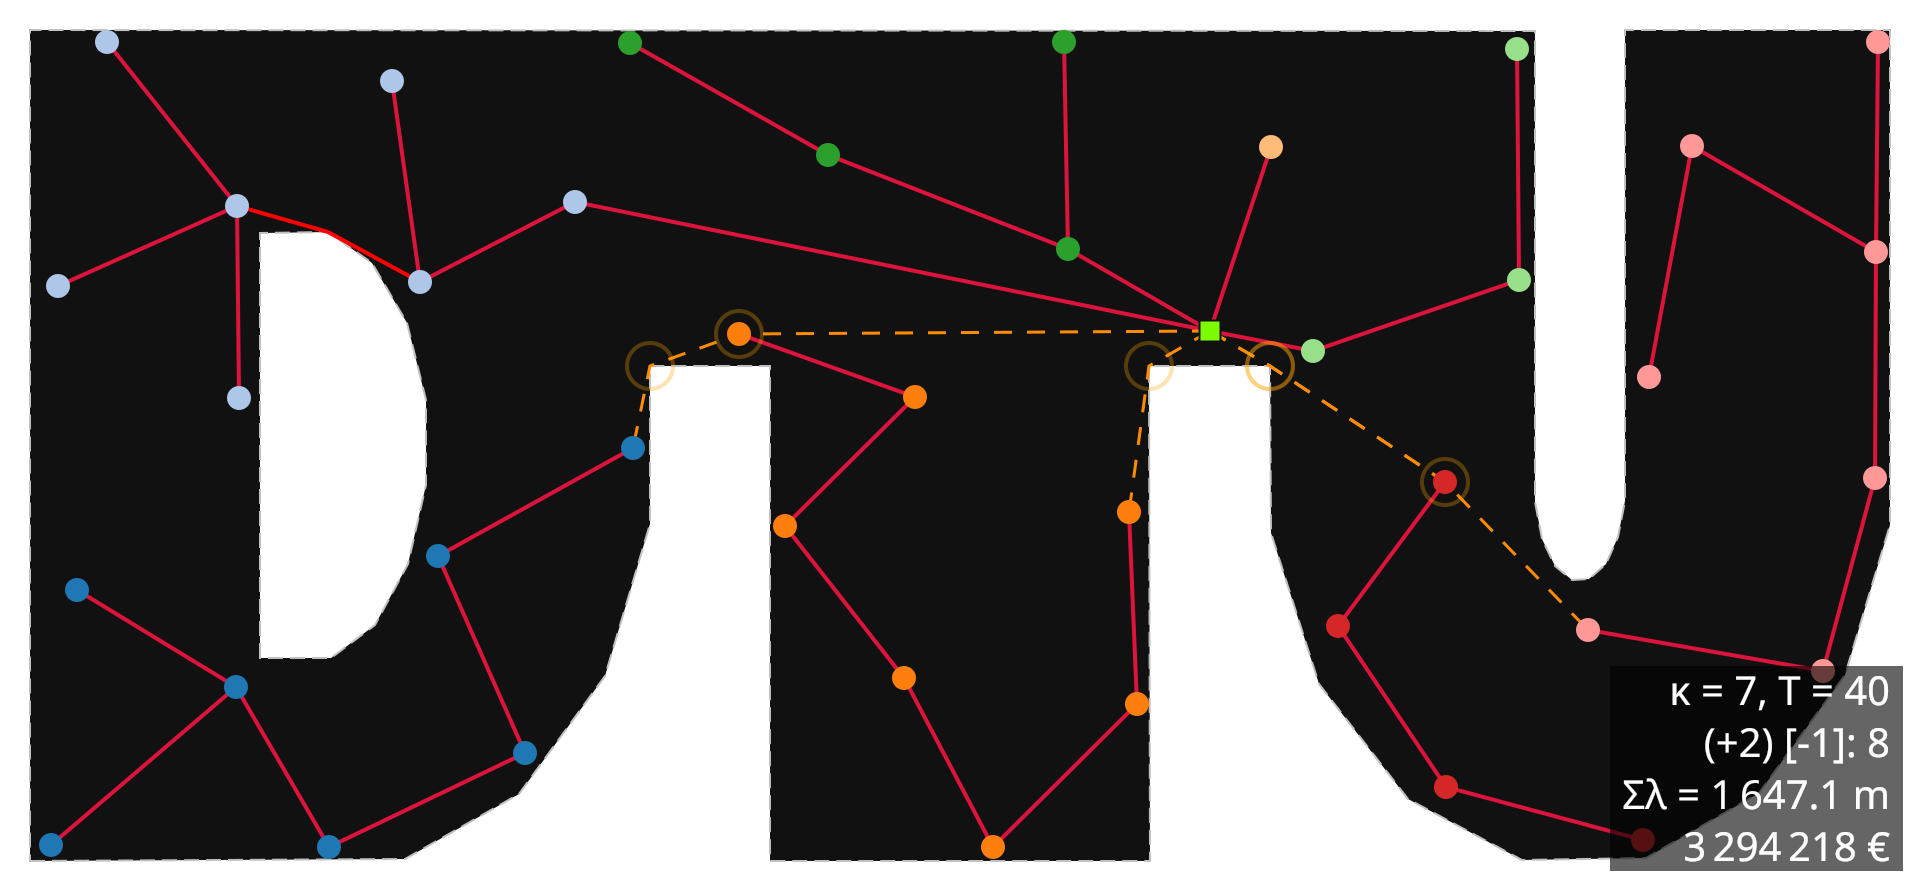

In [4]:
router = EWRouter()
res = wfn.optimize(router=router)
print(wfn.length())
wfn

#### Optimize with user-defined settings.

1707.0505869707563


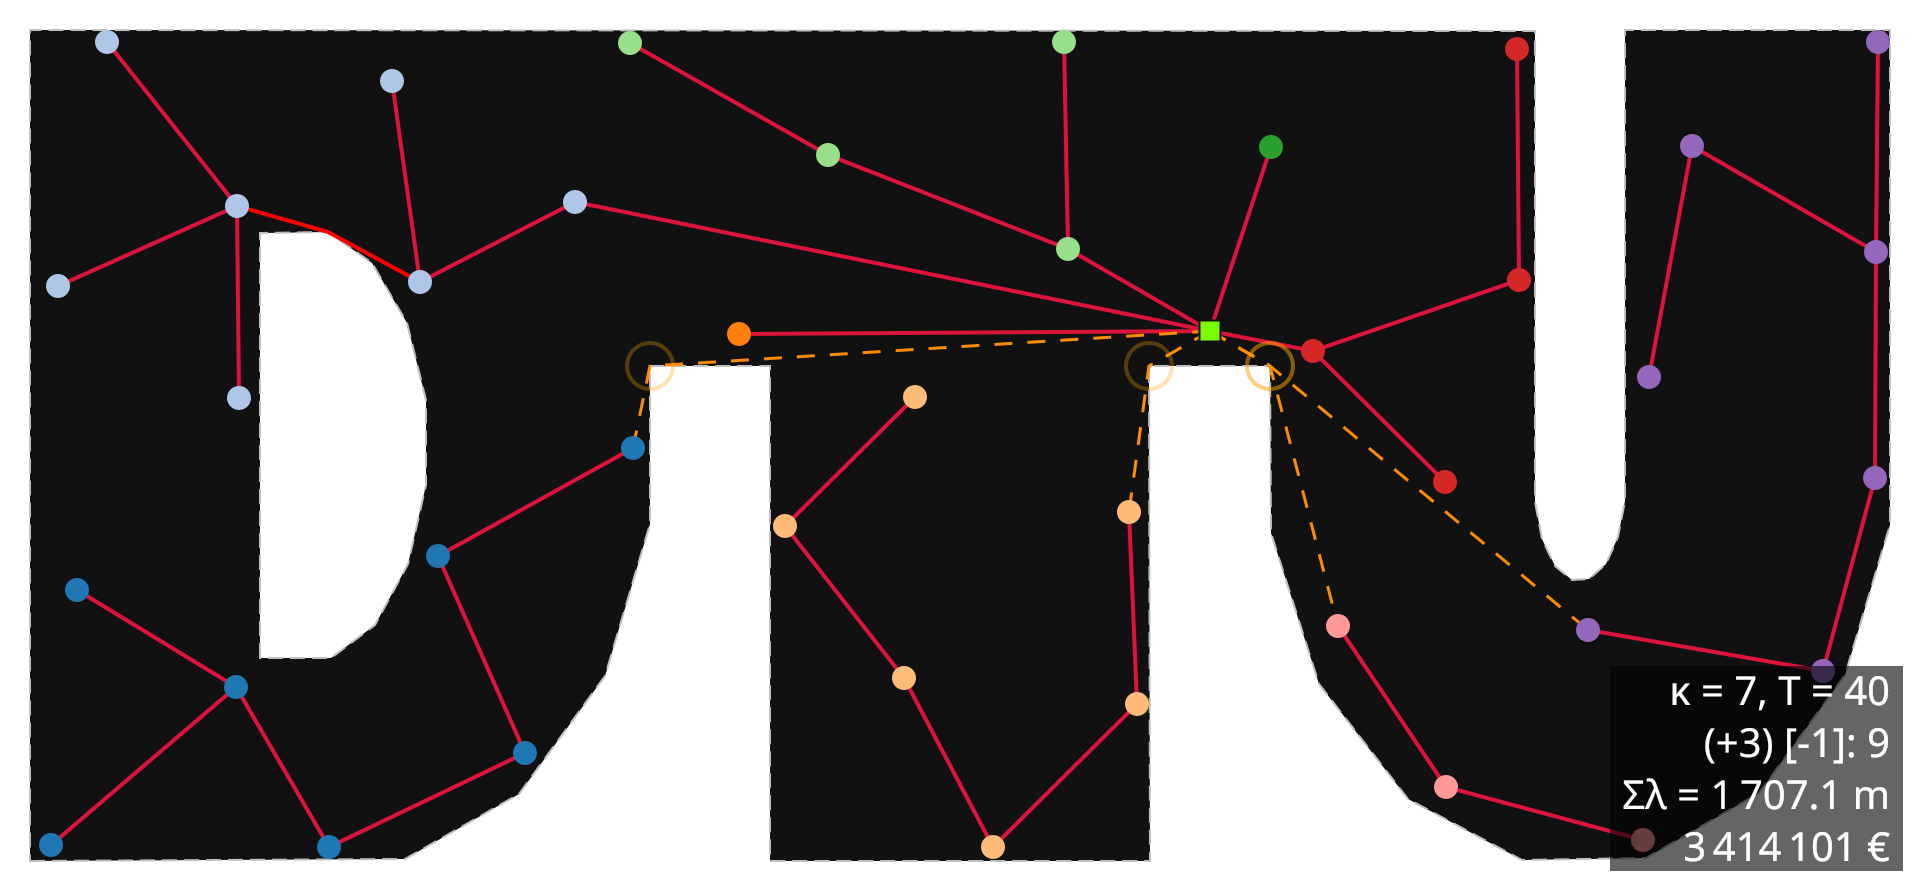

In [5]:
router = EWRouter(        
        maxiter=20000,
        feeder_route='straight',
        verbose=True)
res = wfn.optimize(router=router)
print(wfn.length())
wfn